# Notebook 29 — Denial Reason Analysis

### Persistent Racial Disparities in U.S. Mortgage Approval

**Purpose:** Direct mechanism evidence. HMDA records denial reasons
(credit history, DTI, collateral, employment, etc.) for denied applications.
If Black applicants receive disproportionately MORE credit-history or
collateral denials than observably similar White applicants, this is
direct evidence of differential application of underwriting standards —
not merely an unexplained gap.

**HMDA denial reason codes:**
- 1 = Debt-to-income ratio
- 2 = Employment history  
- 3 = Credit history
- 4 = Collateral
- 5 = Insufficient cash (reserves)
- 6 = Unverifiable information
- 7 = Credit application incomplete
- 8 = Mortgage insurance denied
- 9 = Other

**Design:** For DENIED applications only, test whether race predicts
denial reason conditional on income, LTV, loan amount, and DTI.
Key test: Is P(denial for credit history | denied, Black) >
P(denial for credit history | denied, White) after controls?

**Input:** Raw HMDA files data/hmda_{year}.csv
**Output:** outputs/tables/table_29_denial_reasons.csv,
            outputs/figures/figure_29_denial_reasons.png
**Runtime:** ~45 minutes


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

RAW  = Path("../data")
TABS = Path("../outputs/tables"); TABS.mkdir(exist_ok=True)
FIGS = Path("../outputs/figures"); FIGS.mkdir(exist_ok=True)
YEARS = [2020, 2021, 2022, 2023, 2024]
BLACK_CODE = 3; WHITE_CODE = 5
CHUNK_SIZE = 200_000

# HMDA denial reason codes
DENIAL_LABELS = {
    1: "DTI",
    2: "Employment history",
    3: "Credit history",
    4: "Collateral",
    5: "Insufficient cash",
    6: "Unverifiable info",
    7: "Incomplete application",
    8: "Mortgage insurance denied",
    9: "Other",
}

# Columns to extract
RAW_COLS = [
    "action_taken", "applicant_race_1",
    "income", "loan_amount", "combined_loan_to_value_ratio",
    "debt_to_income_ratio",
    "denial_reason_1", "denial_reason_2",
    "denial_reason_3", "denial_reason_4",
]

def parse_dti(val):
    if pd.isna(val): return np.nan
    s = str(val).strip()
    if s in ("NA", "Exempt", "", "nan", "9999", "Exempted"): return np.nan
    range_map = {"<20%":17.5, "20%-30%":25.0, "30%-36%":33.0,
                 "36%-50%":43.0, "50%-60%":55.0, ">60%":65.0}
    if s in range_map: return range_map[s]
    try:
        v = float(s.replace("%","").replace(">","").replace("<","").strip())
        return v if 0 < v <= 100 else np.nan
    except (ValueError, TypeError): return np.nan

print("="*65)
print("NB29: DENIAL REASON ANALYSIS — DIRECT MECHANISM EVIDENCE")
print("="*65)
print()
print("Loading denied applications from raw HMDA files...")
print("Only action_taken=3 (denied by lender) are included.")
print()


NB29: DENIAL REASON ANALYSIS — DIRECT MECHANISM EVIDENCE

Loading denied applications from raw HMDA files...
Only action_taken=3 (denied by lender) are included.



In [2]:
# Load denied applications and extract denial reasons
denied_dfs = []

for yr in YEARS:
    found = None
    for fname in [f"hmda_{yr}.csv",
                  f"hmda_{yr}_nationwide_all-records_labels.csv"]:
        if (RAW / fname).exists():
            found = RAW / fname; break
    if found is None:
        print(f"  {yr}: NOT FOUND — skip"); continue

    print(f"  {yr}: loading {found.name}...")
    chunks = []
    reader = pd.read_csv(
        found, chunksize=CHUNK_SIZE,
        usecols=lambda c: c in RAW_COLS,
        engine="python", on_bad_lines="skip", dtype=str,
    )
    for chunk in reader:
        race = pd.to_numeric(chunk["applicant_race_1"], errors="coerce")
        act  = pd.to_numeric(chunk["action_taken"],     errors="coerce")
        # DENIED applications only (action_taken == 3)
        mask = race.isin([BLACK_CODE, WHITE_CODE]) & (act == 3)
        chunk = chunk[mask].copy()
        if len(chunk): chunks.append(chunk)

    if not chunks:
        print(f"    No denied rows — skip"); continue

    df_yr = pd.concat(chunks, ignore_index=True)
    df_yr["year"]    = yr
    df_yr["black"]   = (pd.to_numeric(df_yr["applicant_race_1"], errors="coerce") == BLACK_CODE).astype(int)
    df_yr["income_n"]= pd.to_numeric(df_yr["income"],                          errors="coerce")
    df_yr["ltv_n"]   = pd.to_numeric(df_yr["combined_loan_to_value_ratio"],    errors="coerce")
    df_yr["loan_n"]  = pd.to_numeric(df_yr["loan_amount"],                     errors="coerce")
    df_yr["dti_n"]   = df_yr["debt_to_income_ratio"].apply(parse_dti)

    for col in ["denial_reason_1","denial_reason_2","denial_reason_3","denial_reason_4"]:
        df_yr[col+"_n"] = pd.to_numeric(df_yr.get(col), errors="coerce")

    keep = ["year","black","income_n","ltv_n","loan_n","dti_n",
            "denial_reason_1_n","denial_reason_2_n",
            "denial_reason_3_n","denial_reason_4_n"]
    denied_dfs.append(df_yr[[c for c in keep if c in df_yr.columns]])
    print(f"    Denied rows: {len(df_yr):,}")

if not denied_dfs:
    raise RuntimeError("No denied application files found.")

df_denied = pd.concat(denied_dfs, ignore_index=True)
print(f"\nTotal denied applications: {len(df_denied):,}")
print(f"  Black: {df_denied['black'].sum():,}")
print(f"  White: {(df_denied['black']==0).sum():,}")


  2020: loading hmda_2020.csv...
    Denied rows: 2,107,153
  2021: loading hmda_2021.csv...
    Denied rows: 2,108,245
  2022: loading hmda_2022.csv...
    Denied rows: 1,800,965
  2023: loading hmda_2023.csv...
    Denied rows: 1,497,365
  2024: loading hmda_2024.csv...
    Denied rows: 1,516,439

Total denied applications: 9,030,167
  Black: 1,561,910
  White: 7,468,257


In [3]:
# ----------------------------------------------------------------
# ANALYSIS 1: Raw denial reason frequencies by race
# For each denial reason, compute share of Black vs White denials
# ----------------------------------------------------------------
print()
print("="*65)
print("ANALYSIS 1: Denial Reason Frequencies by Race")
print("="*65)
print()
print("For each denial reason code, what % of Black vs White denials")
print("cite this reason (applicants may have multiple reasons).")
print()

# Create a binary indicator for each denial reason
for code in range(1, 10):
    # Check if any of the 4 denial reason columns equals this code
    df_denied[f"deny_{code}"] = (
        (df_denied["denial_reason_1_n"] == code) |
        (df_denied["denial_reason_2_n"] == code) |
        (df_denied["denial_reason_3_n"] == code) |
        (df_denied["denial_reason_4_n"] == code)
    ).astype(int)

freq_rows = []
for code in range(1, 10):
    col = f"deny_{code}"
    if col not in df_denied.columns: continue
    b_rate = df_denied.loc[df_denied["black"]==1, col].mean() * 100
    w_rate = df_denied.loc[df_denied["black"]==0, col].mean() * 100
    diff   = b_rate - w_rate
    n_b    = int(df_denied.loc[df_denied["black"]==1, col].sum())
    n_w    = int(df_denied.loc[df_denied["black"]==0, col].sum())

    # Chi-square test
    b_total = (df_denied["black"]==1).sum()
    w_total = (df_denied["black"]==0).sum()
    cont = np.array([[n_b, b_total - n_b], [n_w, w_total - n_w]])
    chi2, pval, _, _ = stats.chi2_contingency(cont)
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "n.s."

    label = DENIAL_LABELS.get(code, f"Code {code}")
    freq_rows.append({
        "Code": code, "Reason": label,
        "Black_%": round(b_rate, 2), "White_%": round(w_rate, 2),
        "Diff_pp": round(diff, 2), "Sig": sig,
        "N_Black": n_b, "N_White": n_w,
    })
    print(f"  {label:30s}: Black={b_rate:.1f}%  White={w_rate:.1f}%  Diff={diff:+.2f}pp  {sig}")

df_freq = pd.DataFrame(freq_rows)
df_freq.to_csv(TABS / "table_29_denial_reasons.csv", index=False)
print("\nSaved: table_29_denial_reasons.csv")
print()
print("KEY QUESTION: Are Black applicants MORE likely to receive")
print("credit history or collateral denials than White applicants")
print("with similar observables?")



ANALYSIS 1: Denial Reason Frequencies by Race

For each denial reason code, what % of Black vs White denials
cite this reason (applicants may have multiple reasons).

  DTI                           : Black=34.2%  White=34.4%  Diff=-0.20pp  ***
  Employment history            : Black=2.4%  White=2.5%  Diff=-0.10pp  ***
  Credit history                : Black=42.0%  White=31.1%  Diff=+10.92pp  ***
  Collateral                    : Black=12.2%  White=16.6%  Diff=-4.37pp  ***
  Insufficient cash             : Black=5.3%  White=4.2%  Diff=+1.14pp  ***
  Unverifiable info             : Black=5.3%  White=6.1%  Diff=-0.78pp  ***
  Incomplete application        : Black=11.1%  White=13.2%  Diff=-2.10pp  ***
  Mortgage insurance denied     : Black=0.1%  White=0.1%  Diff=+0.01pp  *
  Other                         : Black=13.5%  White=13.6%  Diff=-0.17pp  ***

Saved: table_29_denial_reasons.csv

KEY QUESTION: Are Black applicants MORE likely to receive
credit history or collateral denials than Wh

In [4]:
# ----------------------------------------------------------------
# ANALYSIS 2: Conditional denial reason analysis
# Logit regression: P(denial for reason X | denied, controls)
# Controls: income, LTV, loan amount, DTI
# ----------------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

print()
print("="*65)
print("ANALYSIS 2: Conditional Denial Reason Analysis")
print("Controls: income, LTV, loan amount, DTI")
print("="*65)
print()

# Focus on the most interpretable denial reasons
KEY_REASONS = {
    1: "DTI",
    3: "Credit history",
    4: "Collateral",
    2: "Employment history",
}

features = ["income_n", "ltv_n", "loan_n"]
df_cond = df_denied.dropna(subset=features).copy()

# Add log transforms
for col in ["income_n", "loan_n"]:
    df_cond[col+"_log"] = np.log1p(np.maximum(df_cond[col], 0))

feat_cols = ["income_n_log", "ltv_n", "loan_n_log"]

# Add DTI if available
if df_cond["dti_n"].notna().mean() > 0.3:
    df_cond_dti = df_cond.dropna(subset=["dti_n"])
    feat_cols_dti = feat_cols + ["dti_n"]
    print(f"DTI available for {len(df_cond_dti):,} denied applications — using in conditional analysis")
    analysis_df = df_cond_dti
    analysis_feats = feat_cols_dti
else:
    analysis_df = df_cond
    analysis_feats = feat_cols

cond_rows = []
print(f"\nConditional analysis on {len(analysis_df):,} denied applications with full observables:")
print(f"{'Denial Reason':30s}  {'Marginal Effect':>15s}  {'SE':>8s}  {'Sig':>6s}")
print("-"*65)

for code, label in KEY_REASONS.items():
    col = f"deny_{code}"
    if col not in analysis_df.columns: continue
    
    y = analysis_df[col].values
    X_raw = analysis_df[analysis_feats + ["black"]].values
    
    if y.sum() < 50: continue
    
    sc = StandardScaler()
    X_sc = sc.fit_transform(X_raw)
    
    try:
        lr = LogisticRegression(max_iter=500, random_state=42, C=1.0)
        lr.fit(X_sc, y)
        
        # Marginal effect of Black on P(this denial reason)
        # Average marginal effect: derivative of logistic at observed X
        p_hat = lr.predict_proba(X_sc)[:,1]
        dp = p_hat * (1 - p_hat)  # derivative of sigmoid
        # coefficient index: black is last column
        b_idx = len(analysis_feats)
        b_coef = lr.coef_[0][b_idx]
        b_scaled = b_coef / sc.scale_[b_idx]
        ame = float(np.mean(dp) * b_scaled) * 100  # in pp
        
        # Bootstrap SE (200 reps)
        rng = np.random.RandomState(42)
        ames = []
        for _ in range(200):
            idx_b = rng.choice(len(y), len(y), replace=True)
            lr_b = LogisticRegression(max_iter=300, random_state=42, C=1.0)
            lr_b.fit(X_sc[idx_b], y[idx_b])
            p_b = lr_b.predict_proba(X_sc)[:,1]
            dp_b = p_b * (1 - p_b)
            bc = lr_b.coef_[0][b_idx] / sc.scale_[b_idx]
            ames.append(float(np.mean(dp_b) * bc) * 100)
        se = float(np.std(ames))
        ts = ame / se if se > 0 else 0
        pval = 2 * (1 - stats.norm.cdf(abs(ts)))
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "n.s."
        
        cond_rows.append({
            "Reason": label, "AME_pp": round(ame, 3), "SE": round(se, 3),
            "T_stat": round(ts, 3), "P_value": round(pval, 4), "Sig": sig,
        })
        print(f"  {label:28s}: AME={ame:+.3f}pp  SE={se:.3f}  {sig}")
        
    except Exception as e:
        print(f"  {label}: ERROR — {e}")

df_cond_out = pd.DataFrame(cond_rows)
df_cond_out.to_csv(TABS / "table_29_denial_conditional.csv", index=False)
print("\nSaved: table_29_denial_conditional.csv")
print()
print("INTERPRETATION:")
print("  AME > 0: Black applicants MORE likely to receive this denial reason")
print("  AME < 0: Black applicants LESS likely to receive this denial reason")
print("  conditional on income, LTV, loan amount, DTI")



ANALYSIS 2: Conditional Denial Reason Analysis
Controls: income, LTV, loan amount, DTI

DTI available for 5,505,521 denied applications — using in conditional analysis

Conditional analysis on 5,505,521 denied applications with full observables:
Denial Reason                   Marginal Effect        SE     Sig
-----------------------------------------------------------------
  DTI                         : AME=-3.818pp  SE=0.044  ***
  Credit history              : AME=+9.036pp  SE=0.048  ***
  Collateral                  : AME=-3.165pp  SE=0.043  ***
  Employment history          : AME=+0.023pp  SE=0.017  n.s.

Saved: table_29_denial_conditional.csv

INTERPRETATION:
  AME > 0: Black applicants MORE likely to receive this denial reason
  AME < 0: Black applicants LESS likely to receive this denial reason
  conditional on income, LTV, loan amount, DTI


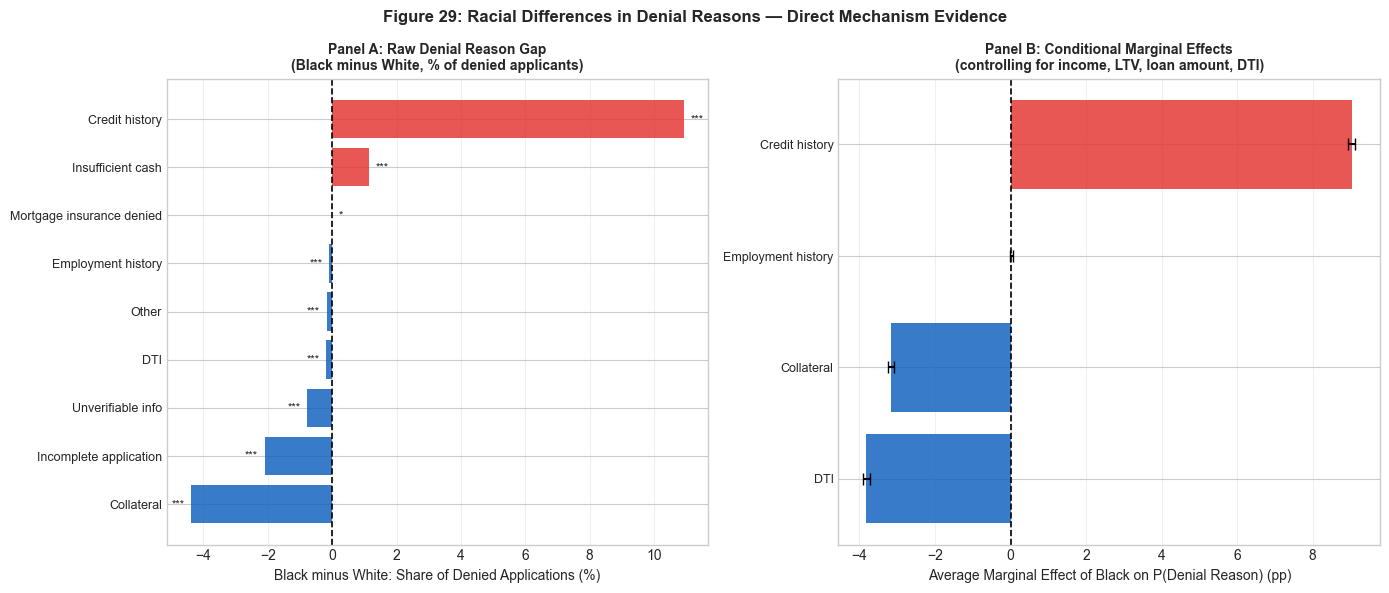

Saved: figure_29_denial_reasons.png

NB29 COMPLETE

MANUSCRIPT IMPLICATION:
  If Black applicants receive MORE credit-history or collateral
  denials conditional on observables, this is direct evidence
  that lenders are applying stricter standards to Black applicants
  on precisely those dimensions that are most subjective.

  This addresses ChatGPT/referee concern about 'no direct
  mechanism evidence' with actual HMDA data, not inference.

Outputs:
  outputs/tables/table_29_denial_reasons.csv
  outputs/tables/table_29_denial_conditional.csv
  outputs/figures/figure_29_denial_reasons.png


In [5]:
# ----------------------------------------------------------------
# ANALYSIS 3: Figure — denial reason gap visualisation
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: Raw frequencies
ax = axes[0]
sorted_rows = df_freq.sort_values("Diff_pp", ascending=True)
colors = ["#E53935" if d > 0 else "#1565C0" for d in sorted_rows["Diff_pp"]]
bars = ax.barh(range(len(sorted_rows)), sorted_rows["Diff_pp"], color=colors, alpha=0.85)
ax.set_yticks(range(len(sorted_rows)))
ax.set_yticklabels(sorted_rows["Reason"], fontsize=9)
ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
ax.set_xlabel("Black minus White: Share of Denied Applications (%)", fontsize=10)
ax.set_title("Panel A: Raw Denial Reason Gap\n(Black minus White, % of denied applicants)",
             fontsize=10, fontweight="bold")
ax.grid(alpha=0.3, axis="x")
# Add significance stars
for i, (_, row) in enumerate(sorted_rows.iterrows()):
    if row["Sig"] in ["***","**","*"]:
        ax.text(row["Diff_pp"] + (0.2 if row["Diff_pp"] >= 0 else -0.2),
                i, row["Sig"], va="center",
                ha="left" if row["Diff_pp"] >= 0 else "right", fontsize=8)

# Panel B: Conditional marginal effects (if available)
ax = axes[1]
if len(cond_rows) > 0:
    df_cond_plot = pd.DataFrame(cond_rows).sort_values("AME_pp", ascending=True)
    colors_c = ["#E53935" if d > 0 else "#1565C0" for d in df_cond_plot["AME_pp"]]
    ax.barh(range(len(df_cond_plot)), df_cond_plot["AME_pp"], color=colors_c, alpha=0.85)
    ax.errorbar(df_cond_plot["AME_pp"], range(len(df_cond_plot)),
                xerr=1.96*df_cond_plot["SE"], fmt="none", color="black", capsize=4)
    ax.set_yticks(range(len(df_cond_plot)))
    ax.set_yticklabels(df_cond_plot["Reason"], fontsize=9)
    ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
    ax.set_xlabel("Average Marginal Effect of Black on P(Denial Reason) (pp)", fontsize=10)
    ax.set_title("Panel B: Conditional Marginal Effects\n(controlling for income, LTV, loan amount, DTI)",
                 fontsize=10, fontweight="bold")
    ax.grid(alpha=0.3, axis="x")
else:
    ax.text(0.5, 0.5, "Conditional analysis\nnot available",
            ha="center", va="center", transform=ax.transAxes, fontsize=12)

fig.suptitle("Figure 29: Racial Differences in Denial Reasons — Direct Mechanism Evidence",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGS / "figure_29_denial_reasons.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: figure_29_denial_reasons.png")
print()
print("="*65)
print("NB29 COMPLETE")
print("="*65)
print()
print("MANUSCRIPT IMPLICATION:")
print("  If Black applicants receive MORE credit-history or collateral")
print("  denials conditional on observables, this is direct evidence")
print("  that lenders are applying stricter standards to Black applicants")
print("  on precisely those dimensions that are most subjective.")
print()
print("  This addresses ChatGPT/referee concern about 'no direct")
print("  mechanism evidence' with actual HMDA data, not inference.")
print()
print("Outputs:")
print("  outputs/tables/table_29_denial_reasons.csv")
print("  outputs/tables/table_29_denial_conditional.csv")
print("  outputs/figures/figure_29_denial_reasons.png")
